## Macroeconomic Drivers of Stock Market Performance

This case study aims to examine the influence of the macroeconomic indicators like interest rate, inflation, growth of GDP, and trading volume on the performance of a stock market. The aim of doing it is to discover trends, relationships and patterns that affect stock returns.

In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


### Loading Dataset


The dataset in this step is loaded into the Python environment as pandas. This gives us an opportunity to browse, read and edit the financial and economic data. The initial step of data analysis is loading the dataset since it is the initial stage of making the data ready to proceed with additional cleaning, exploration, and modeling.

In [2]:
data = pd.read_csv(r"C:\Users\sathiyabama\OneDrive\Documents\TERM 3\Case Study\Assignment1\finance_economics_dataset.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (3000, 24)


,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688


## Data Understanding

The variables included in the dataset include financial and macroeconomic variables including the stock index, close price, the volume of trade, interest rate, inflation rate, and the growth of GDP. These are the variables used in the analysis of the stock performance and economic influence.

In [3]:
print("\nSummary Statistics:\n")
print(data.describe())

print("\nMissing Values:\n")
data.isnull().sum()


Summary Statistics:

        Open Price  Close Price   Daily High   Daily Low  Trading Volume  \
count  3000.000000  3000.000000  3000.000000  3000.00000    3.000000e+03   
mean   2982.094607  2981.249173  3018.887777  2944.32975    5.033864e+08   
std    1151.862689  1151.783841  1151.683485  1151.83490    2.859004e+08   
min    1000.050000   954.520000  1012.130000   917.17000    1.636024e+06   
25%    1994.982500  1997.425000  2035.952500  1955.39750    2.545224e+08   
50%    2970.780000  2977.180000  3006.520000  2939.24500    5.033710e+08   
75%    3974.690000  3982.082500  4015.217500  3934.08750    7.537963e+08   
max    4998.230000  5034.130000  5076.190000  4977.06000    9.999771e+08   

       GDP Growth (%)  Inflation Rate (%)  Unemployment Rate (%)  \
count     3000.000000         3000.000000            3000.000000   
mean         2.608903            5.096830               8.663787   
std          4.287337            2.910513               3.737536   
min         -5.000000

Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Funding (Billion USD)    0
Consumer Sp

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Date                                   3000 non-null   object 
 1   Stock Index                            3000 non-null   object 
 2   Open Price                             3000 non-null   float64
 3   Close Price                            3000 non-null   float64
 4   Daily High                             3000 non-null   float64
 5   Daily Low                              3000 non-null   float64
 6   Trading Volume                         3000 non-null   int64  
 7   GDP Growth (%)                         3000 non-null   float64
 8   Inflation Rate (%)                     3000 non-null   float64
 9   Unemployment Rate (%)                  3000 non-null   float64
 10  Interest Rate (%)                      3000 non-null   float64
 11  Cons

In [5]:
data.head()

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688


In [6]:
print("\nColumn Names:\n", data.columns)


Column Names:
 Index(['Date', 'Stock Index', 'Open Price', 'Close Price', 'Daily High',
       'Daily Low', 'Trading Volume', 'GDP Growth (%)', 'Inflation Rate (%)',
       'Unemployment Rate (%)', 'Interest Rate (%)',
       'Consumer Confidence Index', 'Government Debt (Billion USD)',
       'Corporate Profits (Billion USD)', 'Forex USD/EUR', 'Forex USD/JPY',
       'Crude Oil Price (USD per Barrel)', 'Gold Price (USD per Ounce)',
       'Real Estate Index', 'Retail Sales (Billion USD)',
       'Bankruptcy Rate (%)', 'Mergers & Acquisitions Deals',
       'Venture Capital Funding (Billion USD)',
       'Consumer Spending (Billion USD)'],
      dtype='object')


In [7]:
print("\nData Types:\n", data.dtypes)


Data Types:
 Date                                      object
Stock Index                               object
Open Price                               float64
Close Price                              float64
Daily High                               float64
Daily Low                                float64
Trading Volume                             int64
GDP Growth (%)                           float64
Inflation Rate (%)                       float64
Unemployment Rate (%)                    float64
Interest Rate (%)                        float64
Consumer Confidence Index                  int64
Government Debt (Billion USD)              int64
Corporate Profits (Billion USD)            int64
Forex USD/EUR                            float64
Forex USD/JPY                            float64
Crude Oil Price (USD per Barrel)         float64
Gold Price (USD per Ounce)               float64
Real Estate Index                        float64
Retail Sales (Billion USD)                 int64
Bankru

### Converting Columns to Numeric Format - Data Type Standardization

This is done to translate the columns into numbers to enable the calculation and analysis to be accurate. It also computes the statistical values such as mean, median, mode, minimum, maximum, and the standard deviation in order to know the distribution of the data.

In [8]:
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='ignore')

C:\Users\sathiyabama\AppData\Local\Temp\ipykernel_10956\1900009334.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')


In [9]:
numeric_data = data.select_dtypes(include=[np.number])
desc_stats = pd.DataFrame({
    "Mean": numeric_data.mean(),
    "Median": numeric_data.median(),
    "Mode": numeric_data.mode().iloc[0],
    "Max": numeric_data.max(),
    "Min": numeric_data.min(),
    "Std_Deviation": numeric_data.std()
})
print(desc_stats)

                                               Mean        Median        Mode  \
Open Price                             2.982095e+03  2.970780e+03     1407.57   
Close Price                            2.981249e+03  2.977180e+03     1058.04   
Daily High                             3.018888e+03  3.006520e+03     1279.97   
Daily Low                              2.944330e+03  2.939245e+03     1963.31   
Trading Volume                         5.033864e+08  5.033710e+08  1636024.00   
GDP Growth (%)                         2.608903e+00  2.725000e+00        5.23   
Inflation Rate (%)                     5.096830e+00  5.110000e+00        0.53   
Unemployment Rate (%)                  8.663787e+00  8.710000e+00        3.06   
Interest Rate (%)                      5.218237e+00  5.250000e+00        3.16   
Consumer Confidence Index              8.503600e+01  8.600000e+01      103.00   
Government Debt (Billion USD)          1.536516e+04  1.511350e+04    28044.00   
Corporate Profits (Billion U

### Column Name Cleaning and Standardization for Data Preprocessing

The step removes spaces and special characters that may be present in column names and replaces them with a consistent format. This simplifies the names of the columns in analysis and coding and visualization.

In [10]:
data.columns = [c.strip().replace(' ', '_').replace('(', '').replace(')', '').replace('%','pct').replace('/', '_').replace('.', '') for c in data.columns]

### Histogram of Financial variables

Histograms are employed to depict distribution of the financial variables, being close price, trading volume, and GDP growth. This assists in determining patterns, frequency, spread, and normal distribution or skewed data.

In [11]:
print(data.columns)

Index(['Date', 'Stock_Index', 'Open_Price', 'Close_Price', 'Daily_High',
       'Daily_Low', 'Trading_Volume', 'GDP_Growth_pct', 'Inflation_Rate_pct',
       'Unemployment_Rate_pct', 'Interest_Rate_pct',
       'Consumer_Confidence_Index', 'Government_Debt_Billion_USD',
       'Corporate_Profits_Billion_USD', 'Forex_USD_EUR', 'Forex_USD_JPY',
       'Crude_Oil_Price_USD_per_Barrel', 'Gold_Price_USD_per_Ounce',
       'Real_Estate_Index', 'Retail_Sales_Billion_USD', 'Bankruptcy_Rate_pct',
       'Mergers_&_Acquisitions_Deals', 'Venture_Capital_Funding_Billion_USD',
       'Consumer_Spending_Billion_USD'],
      dtype='object')


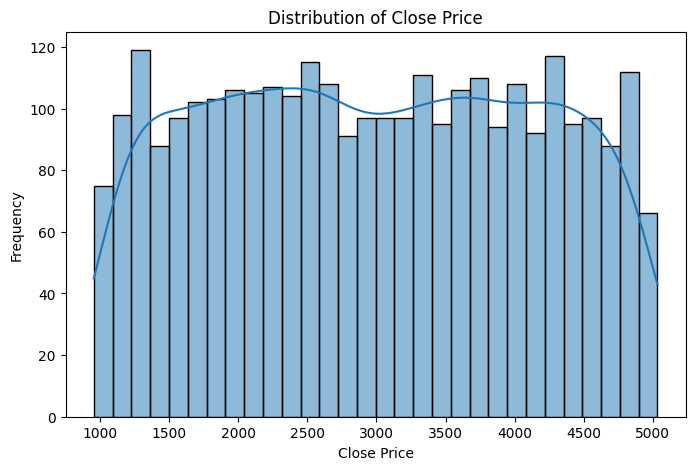

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data["Close_Price"], bins=30, kde=True)

plt.title("Distribution of Close Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

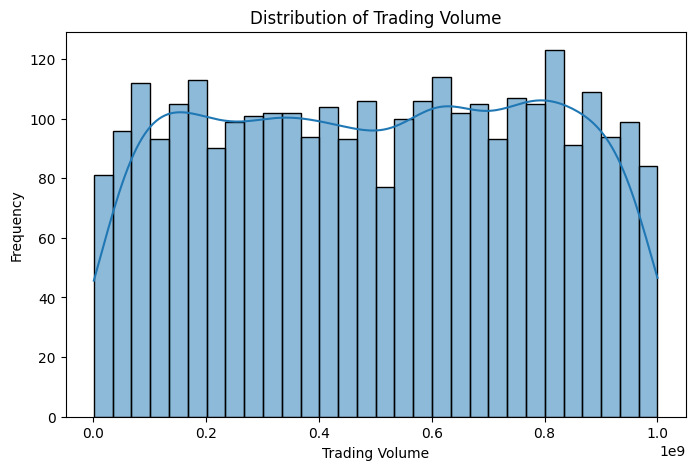

In [13]:


plt.figure(figsize=(8,5))
sns.histplot(data["Trading_Volume"], bins=30, kde=True)

plt.title("Distribution of Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")

plt.show()

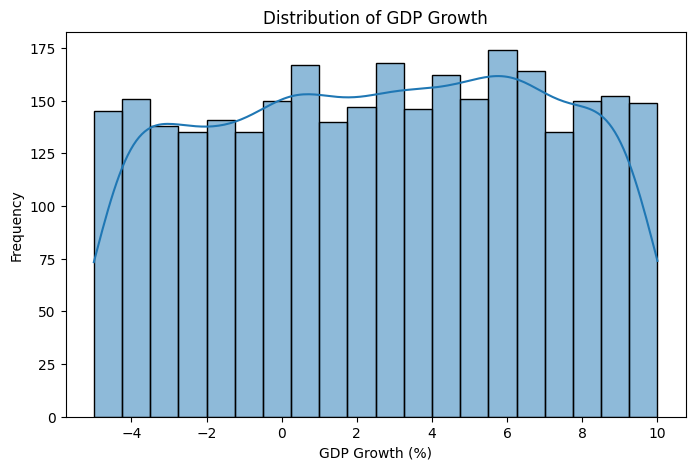

In [14]:

plt.figure(figsize=(8,5))
sns.histplot(data["GDP_Growth_pct"], bins=20, kde=True)

plt.title("Distribution of GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")

plt.show()

### Box Plot for outlier Detection

The allocation of outliers and the distribution of financial variables are depicted in a box plot. It assists in identifying drastic values and the variability and distribution of data.

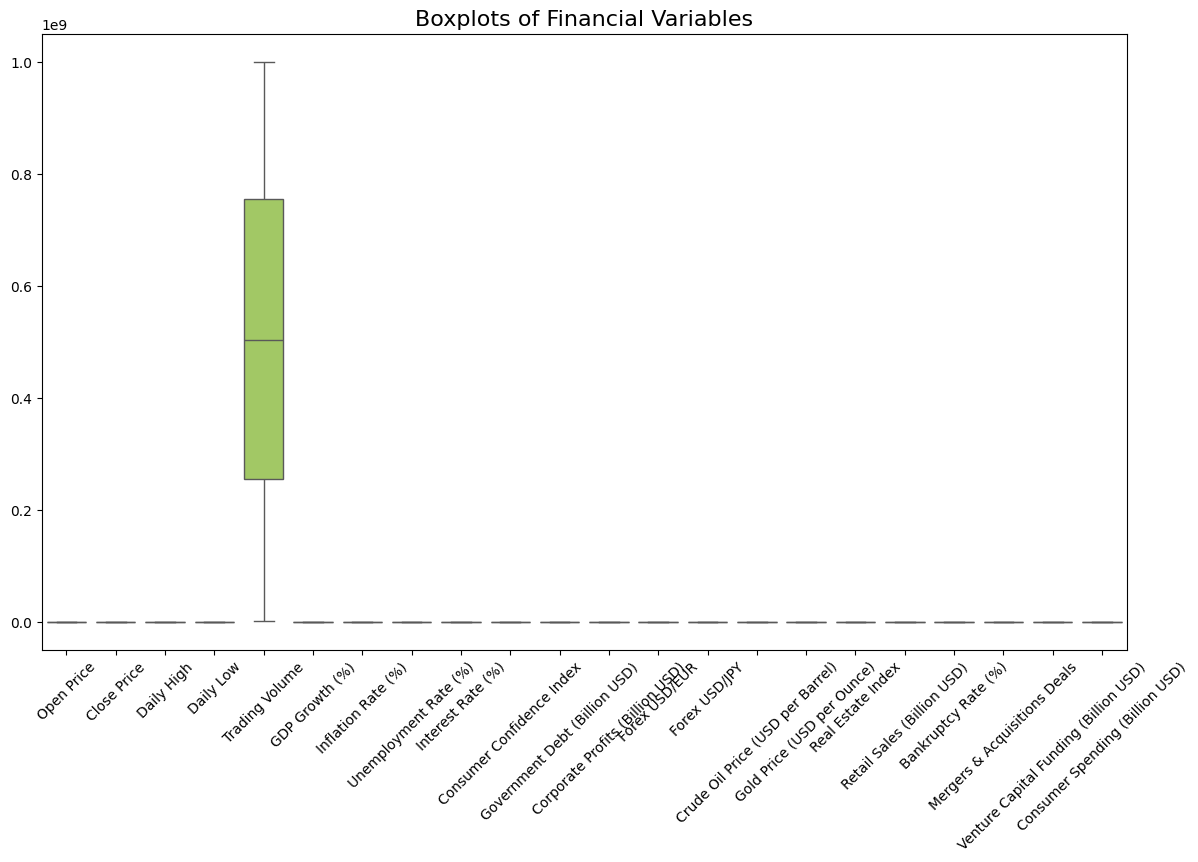

In [15]:
# Boxplot for Outliers Detection

plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_data, palette="Set2")
plt.title("Boxplots of Financial Variables", fontsize=16)
plt.xticks(rotation=45)
plt.show()

### Correlation Analysis

Correlation analysis is used to assess the relationship between financial variables and indicate the level of relationship between them. The heatmap assists in determining positive, negative, or weak relationships among indicators to analyze finances in a better way.

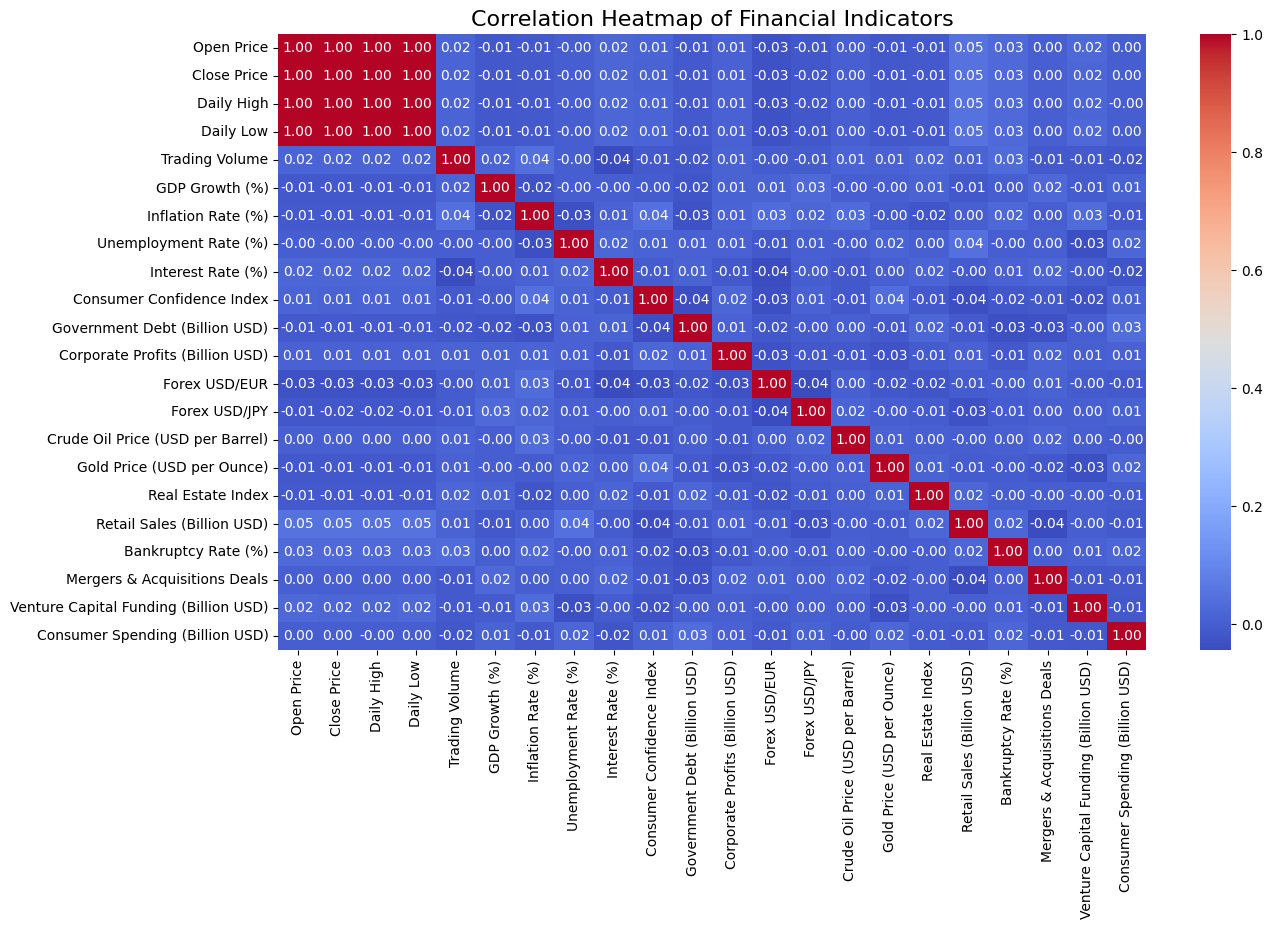

In [16]:
# Correlation Heatmap

plt.figure(figsize=(14, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Financial Indicators", fontsize=16)
plt.show()

### Line Chart for Key Time Based Trends

The visualization of the change across time of important financial variables, including close price, trading volume, interest rate, and inflation rate, is elaborated with a line chart. This assists in finding out the trends, patterns and changes in financial and economic indicators.

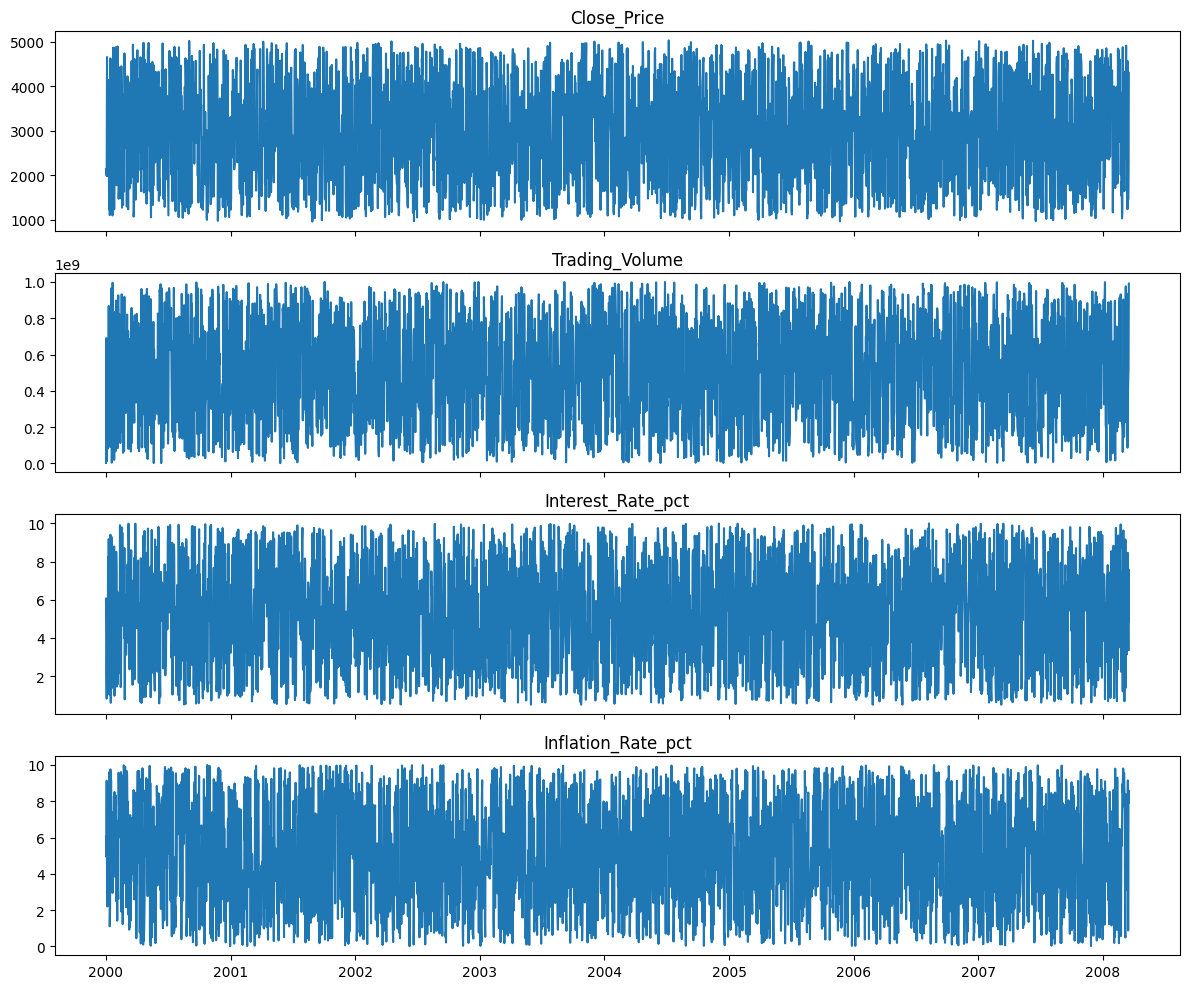

In [17]:
key_variables = [
    "Close_Price",
    "Trading_Volume",
    "Interest_Rate_pct",
    "Inflation_Rate_pct"
]

data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")

fig, axes = plt.subplots(len(key_variables), 1, figsize=(12,10), sharex=True)

for i, col in enumerate(key_variables):
    axes[i].plot(data["Date"], data[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Automatic Date Column Detection, Conversion, and Time-Based Sorting

This step is done automatically to recognize the date column and transform it to a date/time format and sort the information in chronological order. This provides proper time-based analysis and adequate calculation of trends and financial measures.

In [18]:
date_col = None
for c in data.columns:
    if 'date' in c.lower():
        date_col = c
        break

if date_col:
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    df = data.sort_values(date_col)

for col in df.columns:
    data[col] = pd.to_numeric(df[col], errors='ignore')

C:\Users\sathiyabama\AppData\Local\Temp\ipykernel_10956\2953851961.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(df[col], errors='ignore')


In [19]:
print(desc_stats)

                                               Mean        Median        Mode  \
Open Price                             2.982095e+03  2.970780e+03     1407.57   
Close Price                            2.981249e+03  2.977180e+03     1058.04   
Daily High                             3.018888e+03  3.006520e+03     1279.97   
Daily Low                              2.944330e+03  2.939245e+03     1963.31   
Trading Volume                         5.033864e+08  5.033710e+08  1636024.00   
GDP Growth (%)                         2.608903e+00  2.725000e+00        5.23   
Inflation Rate (%)                     5.096830e+00  5.110000e+00        0.53   
Unemployment Rate (%)                  8.663787e+00  8.710000e+00        3.06   
Interest Rate (%)                      5.218237e+00  5.250000e+00        3.16   
Consumer Confidence Index              8.503600e+01  8.600000e+01      103.00   
Government Debt (Billion USD)          1.536516e+04  1.511350e+04    28044.00   
Corporate Profits (Billion U

In [20]:
print("Detected columns:", df.columns.tolist())
print("Date column detected:", date_col)
print("Sample data:\n", df.head(3))

Detected columns: ['Date', 'Stock_Index', 'Open_Price', 'Close_Price', 'Daily_High', 'Daily_Low', 'Trading_Volume', 'GDP_Growth_pct', 'Inflation_Rate_pct', 'Unemployment_Rate_pct', 'Interest_Rate_pct', 'Consumer_Confidence_Index', 'Government_Debt_Billion_USD', 'Corporate_Profits_Billion_USD', 'Forex_USD_EUR', 'Forex_USD_JPY', 'Crude_Oil_Price_USD_per_Barrel', 'Gold_Price_USD_per_Ounce', 'Real_Estate_Index', 'Retail_Sales_Billion_USD', 'Bankruptcy_Rate_pct', 'Mergers_&_Acquisitions_Deals', 'Venture_Capital_Funding_Billion_USD', 'Consumer_Spending_Billion_USD']
Date column detected: Date
Sample data:
         Date Stock_Index  Open_Price  Close_Price  Daily_High  Daily_Low  \
0 2000-01-01   Dow Jones     2128.75      2138.48     2143.70    2100.55   
1 2000-01-02     S&P 500     2046.82      2036.18     2082.83    2009.53   
2 2000-01-03   Dow Jones     1987.92      1985.26     2022.28    1978.37   

   Trading_Volume  GDP_Growth_pct  Inflation_Rate_pct  Unemployment_Rate_pct  \
0      

### Date Formatting, Sorting, and Numeric Data Type Conversion

The step transforms the Date column into a valid datetime format, and arranges the information in chronological order. It also transforms the appropriate columns into numbers in order to make them to be analyzed and calculated correctly.

In [21]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

for col in df.columns:
    if col != "Stock_Index":
        df[col] = pd.to_numeric(df[col], errors="ignore")

C:\Users\sathiyabama\AppData\Local\Temp\ipykernel_10956\1092375678.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


### Calculating Percentage Stock Returns by Index Using Grouped Time-Series Data

This is done to calculate the percentage of change in close price of individual stocks within each index of the stock performance. It is used to examine growth, fall and swings of various stock indices.

In [22]:
df["Stock_Return_pct"] = (
    df.groupby("Stock_Index")["Close_Price"]
      .pct_change() * 100
)

In [23]:
#Displaying and Verifying Dataset Column Names
print("COLUMNS IN DATASET:")
print(df.columns.tolist())

COLUMNS IN DATASET:
['Date', 'Stock_Index', 'Open_Price', 'Close_Price', 'Daily_High', 'Daily_Low', 'Trading_Volume', 'GDP_Growth_pct', 'Inflation_Rate_pct', 'Unemployment_Rate_pct', 'Interest_Rate_pct', 'Consumer_Confidence_Index', 'Government_Debt_Billion_USD', 'Corporate_Profits_Billion_USD', 'Forex_USD_EUR', 'Forex_USD_JPY', 'Crude_Oil_Price_USD_per_Barrel', 'Gold_Price_USD_per_Ounce', 'Real_Estate_Index', 'Retail_Sales_Billion_USD', 'Bankruptcy_Rate_pct', 'Mergers_&_Acquisitions_Deals', 'Venture_Capital_Funding_Billion_USD', 'Consumer_Spending_Billion_USD', 'Stock_Return_pct']


## Predictive Model Development and Evaluation

This section defines a reusable function that builds and evaluates predictive models using different machine learning techniques. The function performs a time-aware train-test split, builds baseline, Linear Regression, and Random Forest models, and evaluates their performance using MAE, RMSE, and R² metrics.

In [24]:
def build_and_evaluate(df, feature_cols, target, label=""):

    # Filter valid rows
    data = df.dropna(subset=feature_cols + [target]).copy()
    data = data.sort_values("Date")

    X = data[feature_cols]
    y = data[target]

    # 80/20 time-aware split
    split = int(len(data) * 0.8)
    X_train = X.iloc[:split]
    X_test = X.iloc[split:]
    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    print("\n" + "=" * 90)
    print(label, "| Target =", target)
    print("=" * 90)
    print("TRAIN SIZE:", len(X_train), "| TEST SIZE:", len(X_test))
    print("FEATURES:", feature_cols)

    # BASELINE MODEL
    baseline_pred = np.repeat(y_train.mean(), len(y_test))
    base_mae = mean_absolute_error(y_test, baseline_pred)
    base_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    base_r2 = r2_score(y_test, baseline_pred)

    print("\n[BASELINE]")
    print("MAE :", base_mae)
    print("RMSE:", base_rmse)
    print("R²  :", base_r2)

    # LINEAR REGRESSION
    lin = LinearRegression()
    lin.fit(X_train, y_train)
    pred_lin = lin.predict(X_test)

    lin_mae = mean_absolute_error(y_test, pred_lin)
    lin_rmse = np.sqrt(mean_squared_error(y_test, pred_lin))
    lin_r2 = r2_score(y_test, pred_lin)

    print("\n[LINEAR REGRESSION]")
    print("MAE :", lin_mae)
    print("RMSE:", lin_rmse)
    print("R²  :", lin_r2)

    coef = pd.DataFrame({
        "Feature": feature_cols,
        "Coefficient": lin.coef_
    }).sort_values("Coefficient", key=lambda x: abs(x), ascending=False)

    print("\nTop Linear Coefficients:")
    print(coef.head(10).to_string(index=False))

    # RANDOM FOREST
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    rf_mae = mean_absolute_error(y_test, pred_rf)
    rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
    rf_r2 = r2_score(y_test, pred_rf)

    print("\n[RANDOM FOREST]")
    print("MAE :", rf_mae)
    print("RMSE:", rf_rmse)
    print("R²  :", rf_r2)

    imp = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": rf.feature_importances_
    }).sort_values("Importance", ascending=False)

    print("\nTop Feature Importances:")
    print(imp.head(10).to_string(index=False))

    # GRADIENT BOOSTING
    gb = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    gb.fit(X_train, y_train)
    pred_gb = gb.predict(X_test)

    gb_mae = mean_absolute_error(y_test, pred_gb)
    gb_rmse = np.sqrt(mean_squared_error(y_test, pred_gb))
    gb_r2 = r2_score(y_test, pred_gb)

    print("\n[GRADIENT BOOSTING]")
    print("MAE :", gb_mae)
    print("RMSE:", gb_rmse)
    print("R²  :", gb_r2)

    return {
    "target": target,
    "baseline": {"MAE": base_mae, "RMSE": base_rmse, "R2": base_r2},
    "linear": {"MAE": lin_mae, "RMSE": lin_rmse, "R2": lin_r2},
    "rf": {"MAE": rf_mae, "RMSE": rf_rmse, "R2": rf_r2},
    "gb": {"MAE": gb_mae, "RMSE": gb_rmse, "R2": gb_r2},
    "lin_coef": coef,
    "rf_importance": imp,
    "y_test": y_test,
    "pred_base": baseline_pred,   # add this
    "pred_lin": pred_lin,         # add this
    "pred_rf": pred_rf,
    "pred_gb": pred_gb
}

In [25]:
build_and_evaluate(
    df,
    feature_cols=["GDP_Growth_pct"],
    target="Close_Price",
    label="TEST MODEL"
)


TEST MODEL | Target = Close_Price
TRAIN SIZE: 2400 | TEST SIZE: 600
FEATURES: ['GDP_Growth_pct']

[BASELINE]
MAE : 1008.29440675
RMSE: 1156.0228933342923
R²  : -0.00014612731474117346

[LINEAR REGRESSION]
MAE : 1009.8253665336198
RMSE: 1156.9179167681993
R²  : -0.0016954058843146047

Top Linear Coefficients:
       Feature  Coefficient
GDP_Growth_pct    -5.912014

[RANDOM FOREST]
MAE : 1120.2674753855094
RMSE: 1352.4078429363976
R²  : -0.368818762688107

Top Feature Importances:
       Feature  Importance
GDP_Growth_pct         1.0

[GRADIENT BOOSTING]
MAE : 1015.0779791572121
RMSE: 1174.4550726732223
R²  : -0.03229400273271432


{'target': 'Close_Price',
 'baseline': {'MAE': 1008.29440675,
  'RMSE': np.float64(1156.0228933342923),
  'R2': -0.00014612731474117346},
 'linear': {'MAE': 1009.8253665336198,
  'RMSE': np.float64(1156.9179167681993),
  'R2': -0.0016954058843146047},
 'rf': {'MAE': 1120.2674753855094,
  'RMSE': np.float64(1352.4078429363976),
  'R2': -0.368818762688107},
 'gb': {'MAE': 1015.0779791572121,
  'RMSE': np.float64(1174.4550726732223),
  'R2': -0.03229400273271432},
 'lin_coef':           Feature  Coefficient
 0  GDP_Growth_pct    -5.912014,
 'rf_importance':           Feature  Importance
 0  GDP_Growth_pct         1.0,
 'y_test': 2400    1482.77
 2401    1449.70
 2402    3093.31
 2403    1990.63
 2404    2423.01
          ...   
 2995    1235.44
 2996    4566.91
 2997    1448.47
 2998    2306.90
 2999    4303.82
 Name: Close_Price, Length: 600, dtype: float64,
 'pred_base': array([2978.45450417, 2978.45450417, 2978.45450417, 2978.45450417,
        2978.45450417, 2978.45450417, 2978.4545041

In [26]:
df["Close_Lag1"] = df["Close_Price"].shift(1)
df["Return_Lag1"] = df["Stock_Return_pct"].shift(1)
df["Volume_Lag1"] = df["Trading_Volume"].shift(1)

This model predicts the stock closing price using macroeconomic indicators such as GDP growth, inflation rate, interest rate, consumer spending, and trading volume. Linear Regression and Random Forest models were used to evaluate whether economic factors can explain variations in stock prices.

In [27]:
features_closeprice = [
    "GDP_Growth_pct",
    "Inflation_Rate_pct",
    "Unemployment_Rate_pct",
    "Interest_Rate_pct",
    "Consumer_Confidence_Index",
    "Government_Debt_Billion_USD",
    "Corporate_Profits_Billion_USD",
    "Retail_Sales_Billion_USD",
    "Consumer_Spending_Billion_USD",
    "Bankruptcy_Rate_pct",
    "Trading_Volume"
]

In [28]:
results_close = build_and_evaluate(
    df,
    feature_cols=features_closeprice,
    target="Close_Price",
    label="MODEL 1 — Predict Close Price"
)


MODEL 1 — Predict Close Price | Target = Close_Price
TRAIN SIZE: 2400 | TEST SIZE: 600
FEATURES: ['GDP_Growth_pct', 'Inflation_Rate_pct', 'Unemployment_Rate_pct', 'Interest_Rate_pct', 'Consumer_Confidence_Index', 'Government_Debt_Billion_USD', 'Corporate_Profits_Billion_USD', 'Retail_Sales_Billion_USD', 'Consumer_Spending_Billion_USD', 'Bankruptcy_Rate_pct', 'Trading_Volume']

[BASELINE]
MAE : 1008.29440675
RMSE: 1156.0228933342923
R²  : -0.00014612731474117346

[LINEAR REGRESSION]
MAE : 1011.891924633468
RMSE: 1158.2263112871933
R²  : -0.003962384148144205

Top Linear Coefficients:
                      Feature  Coefficient
            Interest_Rate_pct    11.891535
          Bankruptcy_Rate_pct    11.457036
        Unemployment_Rate_pct    -7.421644
               GDP_Growth_pct    -6.069458
           Inflation_Rate_pct    -4.903994
    Consumer_Confidence_Index     0.460323
     Retail_Sales_Billion_USD     0.021004
Corporate_Profits_Billion_USD    -0.001464
  Government_Debt_Bill

In [29]:
features_closeprice = [
    "GDP_Growth_pct",
    "Inflation_Rate_pct",
    "Unemployment_Rate_pct",
    "Interest_Rate_pct",
    "Consumer_Confidence_Index",
    "Government_Debt_Billion_USD",
    "Corporate_Profits_Billion_USD",
    "Retail_Sales_Billion_USD",
    "Consumer_Spending_Billion_USD",
    "Bankruptcy_Rate_pct",
    "Trading_Volume"
]

results_close = build_and_evaluate(
    df,
    feature_cols=features_closeprice,
    target="Close_Price",
    label="MODEL 1 — Predict Close Price"
)



MODEL 1 — Predict Close Price | Target = Close_Price
TRAIN SIZE: 2400 | TEST SIZE: 600
FEATURES: ['GDP_Growth_pct', 'Inflation_Rate_pct', 'Unemployment_Rate_pct', 'Interest_Rate_pct', 'Consumer_Confidence_Index', 'Government_Debt_Billion_USD', 'Corporate_Profits_Billion_USD', 'Retail_Sales_Billion_USD', 'Consumer_Spending_Billion_USD', 'Bankruptcy_Rate_pct', 'Trading_Volume']

[BASELINE]
MAE : 1008.29440675
RMSE: 1156.0228933342923
R²  : -0.00014612731474117346

[LINEAR REGRESSION]
MAE : 1011.891924633468
RMSE: 1158.2263112871933
R²  : -0.003962384148144205

Top Linear Coefficients:
                      Feature  Coefficient
            Interest_Rate_pct    11.891535
          Bankruptcy_Rate_pct    11.457036
        Unemployment_Rate_pct    -7.421644
               GDP_Growth_pct    -6.069458
           Inflation_Rate_pct    -4.903994
    Consumer_Confidence_Index     0.460323
     Retail_Sales_Billion_USD     0.021004
Corporate_Profits_Billion_USD    -0.001464
  Government_Debt_Bill

This model forecasts stock return percentage using key macroeconomic indicators including inflation, unemployment rate, interest rate, and corporate profits. The objective is to examine how economic conditions influence short-term stock market returns.

In [30]:
features_returns = [
    "Inflation_Rate_pct",
    "GDP_Growth_pct",
    "Unemployment_Rate_pct",
    "Interest_Rate_pct",
    "Consumer_Confidence_Index",
    "Corporate_Profits_Billion_USD",
    "Government_Debt_Billion_USD",
    "Bankruptcy_Rate_pct"
]

results_returns = build_and_evaluate(
    df,
    feature_cols=features_returns,
    target="Stock_Return_pct",
    label="MODEL 2 — Predict Stock Returns"
)


MODEL 2 — Predict Stock Returns | Target = Stock_Return_pct
TRAIN SIZE: 2397 | TEST SIZE: 600
FEATURES: ['Inflation_Rate_pct', 'GDP_Growth_pct', 'Unemployment_Rate_pct', 'Interest_Rate_pct', 'Consumer_Confidence_Index', 'Corporate_Profits_Billion_USD', 'Government_Debt_Billion_USD', 'Bankruptcy_Rate_pct']

[BASELINE]
MAE : 56.950349001414224
RMSE: 76.0155344813914
R²  : -3.7470983190956986e-05

[LINEAR REGRESSION]
MAE : 57.09270284364295
RMSE: 76.11949139697417
R²  : -0.0027745930397162777

Top Linear Coefficients:
                      Feature  Coefficient
            Interest_Rate_pct     0.637114
        Unemployment_Rate_pct    -0.382830
          Bankruptcy_Rate_pct     0.265176
           Inflation_Rate_pct    -0.174361
               GDP_Growth_pct     0.031897
    Consumer_Confidence_Index    -0.002587
Corporate_Profits_Billion_USD    -0.000399
  Government_Debt_Billion_USD    -0.000265

[RANDOM FOREST]
MAE : 59.31144385359576
RMSE: 77.97772842880715
R²  : -0.05233187515766957

This model predicts market trading volume based on economic indicators, stock price, and stock returns. It helps analyze whether macroeconomic conditions and market performance affect investor trading activity.

In [31]:
features_volume = [
    "Interest_Rate_pct",
    "GDP_Growth_pct",
    "Inflation_Rate_pct",
    "Unemployment_Rate_pct",
    "Corporate_Profits_Billion_USD",
    "Government_Debt_Billion_USD",
    "Stock_Return_pct",
    "Close_Price"
]

results_volume = build_and_evaluate(
    df,
    feature_cols=features_volume,
    target="Trading_Volume",
    label="MODEL 3  Predict Trading Volume"
)


MODEL 3  Predict Trading Volume | Target = Trading_Volume
TRAIN SIZE: 2397 | TEST SIZE: 600
FEATURES: ['Interest_Rate_pct', 'GDP_Growth_pct', 'Inflation_Rate_pct', 'Unemployment_Rate_pct', 'Corporate_Profits_Billion_USD', 'Government_Debt_Billion_USD', 'Stock_Return_pct', 'Close_Price']

[BASELINE]
MAE : 247129369.55021486
RMSE: 284798570.6535606
R²  : -0.00042601581662848886

[LINEAR REGRESSION]
MAE : 246247078.50634953
RMSE: 284396811.31323206
R²  : 0.002394553105476649

Top Linear Coefficients:
                      Feature   Coefficient
           Inflation_Rate_pct  3.938162e+06
            Interest_Rate_pct -3.396881e+06
        Unemployment_Rate_pct  7.861320e+05
             Stock_Return_pct -6.326631e+04
               GDP_Growth_pct -3.677359e+04
                  Close_Price  6.221679e+03
Corporate_Profits_Billion_USD  3.342614e+03
  Government_Debt_Billion_USD -3.056923e+02

[RANDOM FOREST]
MAE : 248566780.20243886
RMSE: 288875368.9414672
R²  : -0.029272554660354944

Top F

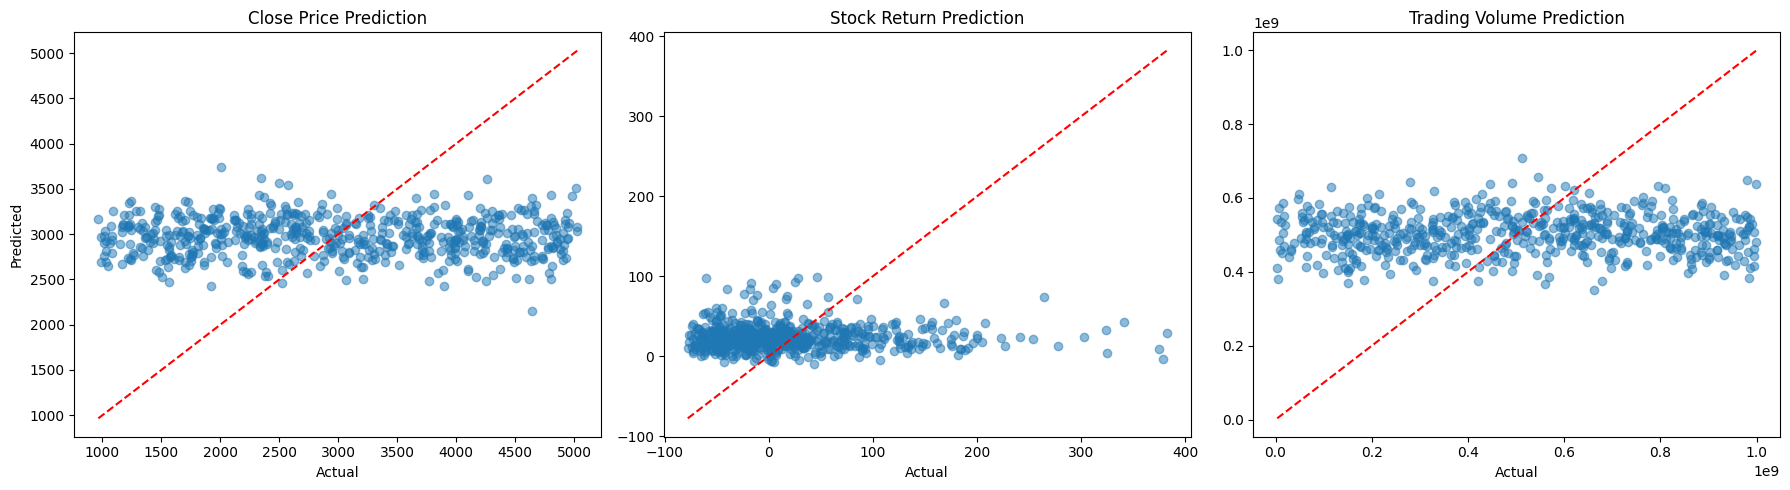

In [32]:

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Close Price
axes[0].scatter(results_close["y_test"], results_close["pred_rf"], alpha=0.5)
axes[0].plot([results_close["y_test"].min(), results_close["y_test"].max()],
             [results_close["y_test"].min(), results_close["y_test"].max()],
             color='red', linestyle='--')
axes[0].set_title("Close Price Prediction")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Stock Return
axes[1].scatter(results_returns["y_test"], results_returns["pred_rf"], alpha=0.5)
axes[1].plot([results_returns["y_test"].min(), results_returns["y_test"].max()],
             [results_returns["y_test"].min(), results_returns["y_test"].max()],
             color='red', linestyle='--')
axes[1].set_title("Stock Return Prediction")
axes[1].set_xlabel("Actual")

# Trading Volume
axes[2].scatter(results_volume["y_test"], results_volume["pred_rf"], alpha=0.5)
axes[2].plot([results_volume["y_test"].min(), results_volume["y_test"].max()],
             [results_volume["y_test"].min(), results_volume["y_test"].max()],
             color='red', linestyle='--')
axes[2].set_title("Trading Volume Prediction")
axes[2].set_xlabel("Actual")

plt.tight_layout()
plt.show()

The scatter plot shows a weak relationship between predicted and actual stock prices. The predictions remain concentrated around the mean value, suggesting that macroeconomic indicators alone provide limited predictive power for daily stock price movements.

In [34]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        results_close["baseline"]["MAE"],
        results_close["linear"]["MAE"],
        results_close["rf"]["MAE"]
    ],
    "RMSE": [
        results_close["baseline"]["RMSE"],
        results_close["linear"]["RMSE"],
        results_close["rf"]["RMSE"]
    ],
    "R2": [
        results_close["baseline"]["R2"],
        results_close["linear"]["R2"],
        results_close["rf"]["R2"]
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline,1008.294407,1156.022893,-0.000146
1,Linear Regression,1011.891925,1158.226311,-0.003962
2,Random Forest,1028.777103,1180.395911,-0.042764


In [35]:
comparison_close = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        results_close["baseline"]["MAE"],
        results_close["linear"]["MAE"],
        results_close["rf"]["MAE"]
    ],
    "RMSE": [
        results_close["baseline"]["RMSE"],
        results_close["linear"]["RMSE"],
        results_close["rf"]["RMSE"]
    ],
    "R2": [
        results_close["baseline"]["R2"],
        results_close["linear"]["R2"],
        results_close["rf"]["R2"]
    ]
})

In [36]:
comparison_returns = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        results_returns["baseline"]["MAE"],
        results_returns["linear"]["MAE"],
        results_returns["rf"]["MAE"]
    ],
    "RMSE": [
        results_returns["baseline"]["RMSE"],
        results_returns["linear"]["RMSE"],
        results_returns["rf"]["RMSE"]
    ],
    "R2": [
        results_returns["baseline"]["R2"],
        results_returns["linear"]["R2"],
        results_returns["rf"]["R2"]
    ]
})

In [37]:
comparison_volume = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        results_volume["baseline"]["MAE"],
        results_volume["linear"]["MAE"],
        results_volume["rf"]["MAE"]
    ],
    "RMSE": [
        results_volume["baseline"]["RMSE"],
        results_volume["linear"]["RMSE"],
        results_volume["rf"]["RMSE"]
    ],
    "R2": [
        results_volume["baseline"]["R2"],
        results_volume["linear"]["R2"],
        results_volume["rf"]["R2"]
    ]
})

In [40]:
comparison_close["Model Number"] = [1, 2, 3]
comparison_close["Target"] = "Close Price"

comparison_returns["Model Number"] = [1, 2, 3]
comparison_returns["Target"] = "Returns"

comparison_volume["Model Number"] = [1, 2, 3]
comparison_volume["Target"] = "Volume"

final_table = pd.concat([
    comparison_close,
    comparison_returns,
    comparison_volume
])

final_table.to_csv("model_results.csv", index=False)

The baseline model performs almost as well as the machine learning models, indicating that predicting the average value provides nearly the same level of accuracy as the trained models. The negative R² values suggest that the models are not able to effectively explain the variation in stock prices. In addition, the Random Forest model does not outperform Linear Regression, which indicates that the dataset may not contain strong predictive signals for forecasting closing prices.

## Conclusion:
This study examined the relationship between macroeconomic indicators and stock market performance using machine learning models such as Linear Regression, Random Forest, and Gradient Boosting. The results indicate that the predictive models did not significantly outperform the baseline model. The evaluation metrics, particularly the negative R² values, show that the models were unable to effectively explain the variation in stock prices. This suggests that the selected macroeconomic variables have limited predictive power for forecasting stock index closing prices in this dataset. Additionally, advanced models like Random Forest and Gradient Boosting did not provide better performance compared to Linear Regression. This may be because stock market movements are influenced by many additional factors. Elements such as investor sentiment, global economic events, and company-level performance can strongly impact market behavior. Since these factors were not included in the dataset, the predictive capability of the models remained limited. Overall, the results highlight the complexity of financial markets. Future research could improve prediction accuracy by incorporating additional financial indicators and more advanced modeling techniques.